<a href="https://colab.research.google.com/github/kr1347/Racial-Classification-via-CNN/blob/main/Racial_highest(Final).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/CSCE_3214/CNN_Assign/UTK_Face.zip'
extract_dir = '/content/UTKFace'

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Dataset extracted!")


Dataset extracted!


In [ ]:
import glob

image_paths = glob.glob('/content/UTKFace/**/*.jpg', recursive=True)
print("Total images found:", len(image_paths))
print("First 5 image paths:", image_paths[:5])


Total images found: 66976
First 5 image paths: ['/content/UTKFace/crop_part1/5_1_0_20170109193659649.jpg.chip.jpg', '/content/UTKFace/crop_part1/80_1_0_20170110182353061.jpg.chip.jpg', '/content/UTKFace/crop_part1/72_1_3_20170109151014965.jpg.chip.jpg', '/content/UTKFace/crop_part1/31_1_4_20170103182224513.jpg.chip.jpg', '/content/UTKFace/crop_part1/7_0_0_20170110215633251.jpg.chip.jpg']


In [ ]:
import tensorflow as tf
import os
import numpy as np
import cv2
from glob import glob

AUTOTUNE = tf.data.AUTOTUNE
IMG_SIZE = 128
BATCH_SIZE = 8
NUM_CLASSES = 5

# Step 1: Get image paths
image_paths = glob('/content/UTKFace/**/*.jpg')
print(f"Total images found: {len(image_paths)}")

# Step 2: Extract label from filename
def get_label_from_filename(path):
    base = os.path.basename(path)
    try:
        race = int(base.split('_')[2])
        if race <= 4:
            return race
        else:
            return -1
    except:
        return -1

# Step 3: Preprocessing function
def process_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, tf.one_hot(label, NUM_CLASSES)

# Step 4: Data augmentation
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    return image, label

# Step 5: Build tf.data.Dataset
def build_dataset(paths, training=True):
    labels = [get_label_from_filename(p) for p in paths]
    paths_filtered, labels_filtered = zip(*[(p, l) for p, l in zip(paths, labels) if l != -1])
    ds = tf.data.Dataset.from_tensor_slices((list(paths_filtered), list(labels_filtered)))
    ds = ds.shuffle(buffer_size=20000)
    ds = ds.map(process_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


Total images found: 33488


In [ ]:
# Step 6: Split paths manually
from sklearn.model_selection import train_test_split
train_paths, val_paths = train_test_split(image_paths, test_size=0.2, random_state=42)

train_ds = build_dataset(train_paths, training=True)
val_ds = build_dataset(val_paths, training=False)


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Dropout, GlobalAveragePooling2D, Dense

def cnn_128(input_shape=(128, 128, 3), num_classes=5):
    inputs = Input(shape=input_shape)

    # Block 1
    x = Conv2D(64, (3, 3), strides=1, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(64, (3, 3), strides=1, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)

    # Block 2
    x = Conv2D(128, (3, 3), strides=1, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(128, (3, 3), strides=1, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)

    # Block 3
    x = Conv2D(256, (3, 3), strides=1, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(256, (3, 3), strides=1, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)

    # Block 4
    x = Conv2D(512, (3, 3), strides=1, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(512, (3, 3), strides=1, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)

    # Global Pooling and Classification
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

model = cnn_128()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             

 Total params: 4,825,669 (18.41 MB)

 Trainable params: 4,821,829 (18.39 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [ ]:
from keras.optimizers import AdamW

model = cnn_128(input_shape=(128, 128, 3), num_classes=NUM_CLASSES)

def focal_loss(alpha, gamma=3.0):
    alpha = tf.constant(alpha, dtype=tf.float32)
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1. - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        loss = weight * cross_entropy
        return tf.reduce_sum(loss, axis=1)
    return loss


model.compile(
    optimizer=AdamW(learning_rate=1e-4, weight_decay=1e-5),
    loss=focal_loss(gamma=3.0, alpha=0.50),
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
    tf.keras.callbacks.ModelCheckpoint('best_utk_model.h5', save_best_only=True)
]


In [ ]:
from sklearn.utils import class_weight
import numpy as np

class_weights_dict = {
    0: 1.0,    # White
    1: 3.0,    # Black
    2: 3.0,    # Asian
    3: 3.0,    # Indian
    4: 5.0     # Others
}
# Add to model.fit
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights_dict,
    callbacks=callbacks
)


Epoch 1/15
3349/3349 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3278 - loss: 0.9395

3349/3349 ━━━━━━━━━━━━━━━━━━━━ 60s 13ms/step - accuracy: 0.3278 - loss: 0.9394 - val_accuracy: 0.5582 - val_loss: 0.2595 - learning_rate: 1.0000e-04
Epoch 2/15
3345/3349 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5512 - loss: 0.6015

3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.5512 - loss: 0.6014 - val_accuracy: 0.5691 - val_loss: 0.2570 - learning_rate: 1.0000e-04
Epoch 3/15
3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.6480 - loss: 0.4635 - val_accuracy: 0.3667 - val_loss: 0.3717 - learning_rate: 1.0000e-04
Epoch 4/15
3345/3349 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6756 - loss: 0.4249

3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.6756 - loss: 0.4249 - val_accuracy: 0.6350 - val_loss: 0.1685 - learning_rate: 1.0000e-04
Epoch 5/15
3348/3349 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6976 - loss: 0.3864

3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.6976 - loss: 0.3864 - val_accuracy: 0.7279 - val_loss: 0.1529 - learning_rate: 1.0000e-04
Epoch 6/15
3346/3349 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7118 - loss: 0.3610

...

3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.7336 - loss: 0.3092 - val_accuracy: 0.7665 - val_loss: 0.1263 - learning_rate: 1.0000e-04
Epoch 9/15
3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.7565 - loss: 0.2802 - val_accuracy: 0.3997 - val_loss: 0.6058 - learning_rate: 1.0000e-04
Epoch 10/15
3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.7681 - loss: 0.2611 - val_accuracy: 0.7337 - val_loss: 0.1435 - learning_rate: 1.0000e-04
Epoch 11/15
3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.7717 - loss: 0.2490 - val_accuracy: 0.7406 - val_loss: 0.1311 - learning_rate: 1.0000e-04
Epoch 12/15
3344/3349 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8123 - loss: 0.1989

3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.8123 - loss: 0.1989 - val_accuracy: 0.7688 - val_loss: 0.1204 - learning_rate: 5.0000e-05
Epoch 13/15
3343/3349 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8220 - loss: 0.1740

3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.8220 - loss: 0.1740 - val_accuracy: 0.8390 - val_loss: 0.0871 - learning_rate: 5.0000e-05
Epoch 14/15
3347/3349 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8320 - loss: 0.1620

3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.8320 - loss: 0.1620 - val_accuracy: 0.8417 - val_loss: 0.0864 - learning_rate: 5.0000e-05
Epoch 15/15
3344/3349 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8436 - loss: 0.1460

3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.8436 - loss: 0.1460 - val_accuracy: 0.8439 - val_loss: 0.0821 - learning_rate: 5.0000e-05


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    initial_epoch=15,
    callbacks=callbacks
)


Epoch 16/25
3349/3349 ━━━━━━━━━━━━━━━━━━━━ 44s 11ms/step - accuracy: 0.8799 - loss: 0.0501 - val_accuracy: 0.8055 - val_loss: 0.0910 - learning_rate: 5.0000e-05
Epoch 17/25
3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.8824 - loss: 0.0483 - val_accuracy: 0.8315 - val_loss: 0.0862 - learning_rate: 5.0000e-05
Epoch 18/25
3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.8845 - loss: 0.0471 - val_accuracy: 0.8105 - val_loss: 0.0972 - learning_rate: 5.0000e-05
Epoch 19/25
3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.8849 - loss: 0.0440 - val_accuracy: 0.8421 - val_loss: 0.1018 - learning_rate: 5.0000e-05
Epoch 20/25
3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.8928 - loss: 0.0407 - val_accuracy: 0.8350 - val_loss: 0.1152 - learning_rate: 5.0000e-05
Epoch 21/25
3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.9071 - loss: 0.0321 - val_accuracy: 0.8544 - val_loss: 0.0877 - learning_rate: 2.5000e-05
Epoch 22/25
3346/3349 ━━━━━━━━━━━━━━━━━

3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.9220 - loss: 0.0277 - val_accuracy: 0.8742 - val_loss: 0.0773 - learning_rate: 2.5000e-05
Epoch 23/25
3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.9258 - loss: 0.0257 - val_accuracy: 0.8429 - val_loss: 0.0946 - learning_rate: 2.5000e-05
Epoch 24/25
3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.9297 - loss: 0.0240 - val_accuracy: 0.8381 - val_loss: 0.1020 - learning_rate: 2.5000e-05
Epoch 25/25
3343/3349 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9396 - loss: 0.0201

3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.9396 - loss: 0.0201 - val_accuracy: 0.8698 - val_loss: 0.0753 - learning_rate: 2.5000e-05


In [ ]:
model.compile(
    optimizer=AdamW(learning_rate=1e-4, weight_decay=1e-5),
    loss=focal_loss(gamma=3.0, alpha=0.50),
    metrics=['accuracy']
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35,
    initial_epoch=25,
    callbacks=callbacks
)

Epoch 26/35
3349/3349 ━━━━━━━━━━━━━━━━━━━━ 48s 11ms/step - accuracy: 0.8715 - loss: 0.0608 - val_accuracy: 0.8063 - val_loss: 0.0817 - learning_rate: 1.0000e-04
Epoch 27/35
3349/3349 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8731 - loss: 0.0567

3349/3349 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - accuracy: 0.8731 - loss: 0.0567 - val_accuracy: 0.8568 - val_loss: 0.0602 - learning_rate: 1.0000e-04
Epoch 28/35
3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.8820 - loss: 0.0516 - val_accuracy: 0.8323 - val_loss: 0.0638 - learning_rate: 1.0000e-04
Epoch 29/35
3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.8842 - loss: 0.0477 - val_accuracy: 0.7858 - val_loss: 0.0933 - learning_rate: 1.0000e-04
Epoch 30/35
3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.8861 - loss: 0.0450 - val_accuracy: 0.6606 - val_loss: 0.3062 - learning_rate: 1.0000e-04
Epoch 31/35
3347/3349 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9180 - loss: 0.0294

3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.9180 - loss: 0.0294 - val_accuracy: 0.9123 - val_loss: 0.0432 - learning_rate: 5.0000e-05
Epoch 32/35
3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.9311 - loss: 0.0240 - val_accuracy: 0.8805 - val_loss: 0.0615 - learning_rate: 5.0000e-05
Epoch 33/35
3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.9333 - loss: 0.0216 - val_accuracy: 0.8956 - val_loss: 0.0518 - learning_rate: 5.0000e-05
Epoch 34/35
3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.9394 - loss: 0.0200 - val_accuracy: 0.9098 - val_loss: 0.0456 - learning_rate: 5.0000e-05
Epoch 35/35
3349/3349 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.9518 - loss: 0.0142 - val_accuracy: 0.8839 - val_loss: 0.0504 - learning_rate: 2.5000e-05


#Evaluation Metrics

In [ ]:
from tensorflow.keras.models import load_model
from google.colab import drive

drive.mount('/content/drive')

model_path = '/content/drive/MyDrive/best_utk_model(Final).h5'
model = load_model(model_path, compile=False)
print("Model loaded successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded successfully.


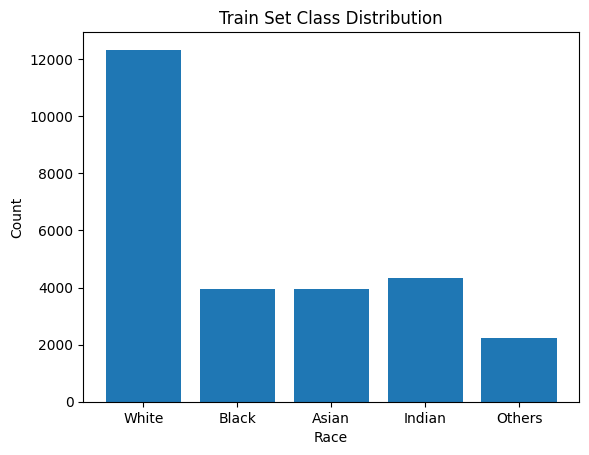

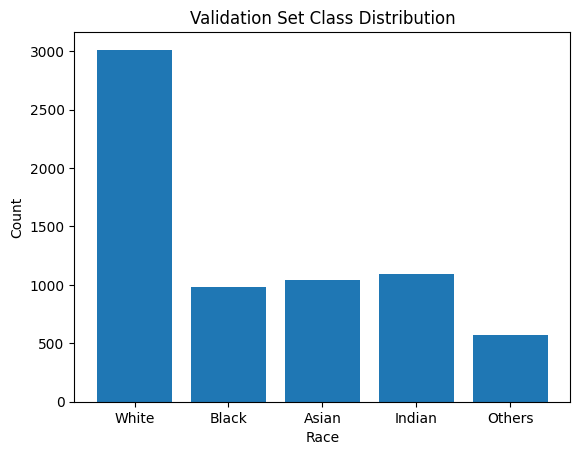

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

def get_label_from_filename(path):
    base = os.path.basename(path)
    try:
        race = int(base.split('_')[2])
        return race if race <= 4 else -1
    except:
        return -1

train_labels = [get_label_from_filename(p) for p in train_paths if get_label_from_filename(p) != -1]
val_labels = [get_label_from_filename(p) for p in val_paths if get_label_from_filename(p) != -1]

train_counter = Counter(train_labels)
val_counter = Counter(val_labels)
race_labels = ['White', 'Black', 'Asian', 'Indian', 'Others']

def plot_distribution(counter, title):
    plt.bar(race_labels, [counter.get(i, 0) for i in range(5)])
    plt.title(title)
    plt.xlabel("Race")
    plt.ylabel("Count")
    plt.show()

plot_distribution(train_counter, "Train Set Class Distribution")
plot_distribution(val_counter, "Validation Set Class Distribution")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━

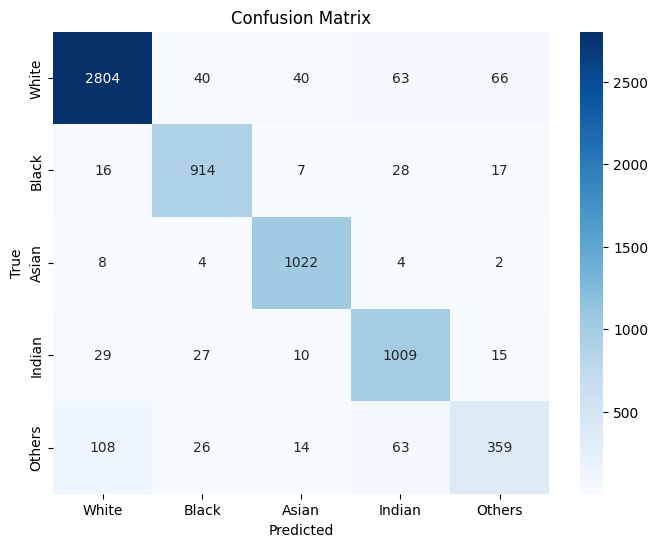

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

val_ds_raw = build_dataset(val_paths, training=False)

y_true = []
y_pred = []

for images, labels in val_ds_raw:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=race_labels))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=race_labels, yticklabels=race_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

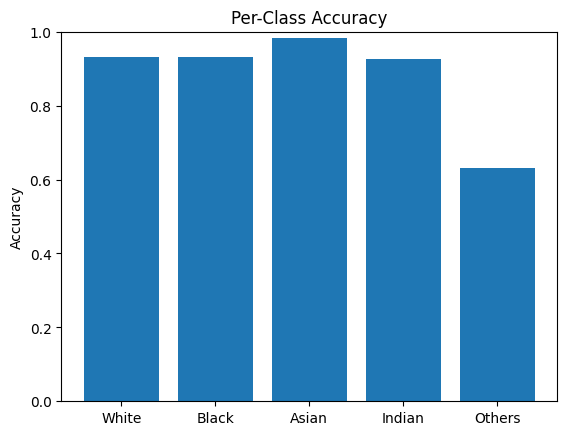

In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np

y_true_np = np.array(y_true)
y_pred_np = np.array(y_pred)

per_class_acc = []
for i in range(NUM_CLASSES):
    idx = np.where(y_true_np == i)[0]
    acc = accuracy_score(y_true_np[idx], y_pred_np[idx])
    per_class_acc.append(acc)

plt.bar(race_labels, per_class_acc)
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy")
plt.ylim(0, 1)
plt.show()